# Bivariate Assignment - Question and Answers explanation

# Download the dataset

In [2]:
#Importing the required library files
import pandas as pd
#Reading our dataset from Preplacementdata.csv
dataset=pd.read_csv("Preplacementdata.csv")
#Checking dataset values to know how it's look like
dataset

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
0,1,67.00,91.00,58.00,55.0,58.80,270000.0,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed
1,2,79.33,78.33,77.48,86.5,66.28,200000.0,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed
2,3,65.00,68.00,64.00,75.0,57.80,250000.0,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed
3,4,56.00,52.00,52.00,66.0,59.43,0.0,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed
4,5,85.80,73.60,73.30,96.8,55.50,425000.0,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,80.60,82.00,77.60,91.0,74.49,400000.0,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
211,212,58.00,60.00,72.00,74.0,53.62,275000.0,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed
212,213,67.00,67.00,73.00,59.0,69.72,295000.0,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed
213,214,74.00,66.00,58.00,70.0,60.23,204000.0,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed


# 1) Replace the NaN values with correct value.

In [3]:
#Checking whether our dataset is containing any null values in any of the columns.
'''Here the necessity to make sure no NaN values in dataset is, Handling NaN (Not a Number) values is a critical part of data
cleaning in Python. Most libraries, like Pandas and NumPy, cannot perform calculations or build machine learning models 
if the data contains these gaps.'''
#Verifying whether columns having any NaN values or not.
dataset.isna().sum()

#Replace NaN values with some value can be done using below types.
'''
1. Replace with a single value
2. Replace with column mean/median/mode
3. Forward fill / Backward fill
4. Replace NaN in specific column only
5. Make it permanent with df.fillna(0, inplace=True)  # Changes dataset directly
'''

sl_no             0
ssc_p             0
hsc_p             0
degree_p          0
etest_p           0
mba_p             0
salary            0
gender            0
ssc_b             0
hsc_b             0
hsc_s             0
degree_t          0
workex            0
specialisation    0
status            0
dtype: int64

# 2) How many of them are not placed

In [4]:
#Here finding out the student how many of them placed and not placed.
dataset['status'].value_counts()

Placed        148
Not Placed     67
Name: status, dtype: int64

# 3) Find the reason for non placement from dataset.

In [5]:
#Here we are finding the reason, why students not placed.
#Reason for placed
dataset[dataset['status'] == 'Placed']['salary'].describe()

count       148.000000
mean     288655.405405
std       93457.452420
min      200000.000000
25%      240000.000000
50%      265000.000000
75%      300000.000000
max      940000.000000
Name: salary, dtype: float64

In [6]:
#Reason for not placed
dataset[dataset['status'] == 'Not Placed']['salary'].describe()

count    67.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: salary, dtype: float64

In [ ]:
#Now, we can see non placed students they are still sutdying, so no salary they are getting.

# 4) What kind of relation between salary and mba_p

In [8]:
#Here we are finding how the salary and mba_p calumns correlating
dataset['salary'].corr(dataset['mba_p']) # Pearson correlation

0.1398227389261557

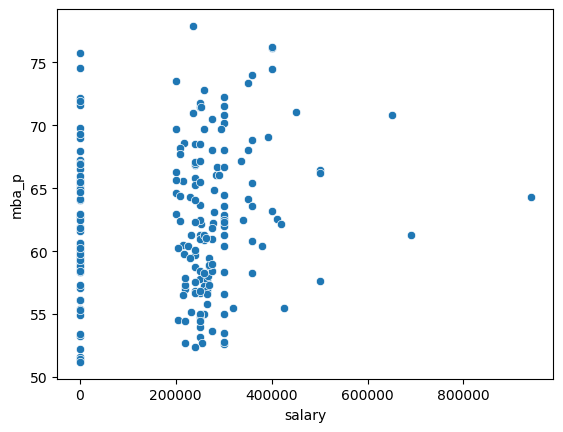

In [9]:
#Importing seaborn library for displaying visually
import seaborn as sns
sns.scatterplot(x='salary', y='mba_p', data=dataset)

In [13]:
#To find full correlation matrix for all numeric columns we can use below but it works for pandas version > 2
'''dataset.corr(numeric_only=True)  # Shows relation between every pair'''
#Here verifying the pandas version
print(pd.__version__)

1.3.5


In [12]:
#Here is the correct method to get full correlation matrix of all numeric columns, for the pandas versions < 2
dataset.select_dtypes(include='number').corr()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.002543
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823
salary,0.002543,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000


# 5) Which specialization is getting minimum salary?

In [16]:
#Here is the method to find out which specializations getting mininum salary
placed_df = dataset[dataset['salary'] > 0]
placed_df.groupby('specialisation')['salary'].min().sort_values()
#If we observe here, two of the specializations are getting minimum salary

specialisation
Mkt&Fin    200000.0
Mkt&HR     200000.0
Name: salary, dtype: float64

# 6) How many of them getting above 500000 salary?

In [17]:
# If salary is in actual rupees like 500000
above_5L = (dataset['salary'] > 500000).sum()(
print(above_5L))

3


In [22]:
#To see group by specialization too
dataset[dataset['salary'] > 500000]['specialisation'].value_counts()
#Here, we see 3 of Mkt&Fin department employees getting salary above 500000

Mkt&Fin    3
Name: specialisation, dtype: int64

# 7) Test the Analysis variance of between etest_p and mba_p at significance level 5%
# Make decision using Hypothesis Testing

Levene stat = 157.8148
p-value = 0.0000
Reject H0: Variances are significantly different at 5% level
Variance of etest_p: 176.25101837861337
Variance of mba_p: 34.028375666159526


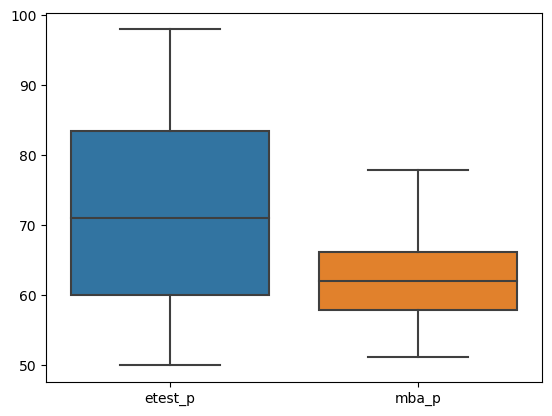

In [27]:
'''
To perform an Analysis of Variance (ANOVA) between etest_p and mba_p, we are essentially testing whether the means of these 
two groups are significantly different.
Here is the hypothesis testing framework for this problem:
1. Define Hypotheses
Null Hypothesis (H0): There is no significant difference between the mean scores of etest_p and mba_p
2. Alternative Hypothesis (Ha): There is a significant difference between the mean scores.
3. Set Significance Level p = 0.05 (5%)
4. Calculate the Test Statistic (F-test)
In a One-Way ANOVA, we calculate the F-statistic, which compares the variance between the groups to the variance 
within the groups: F = Mean Square Between (MSB) / Mean Square Within (MSW)
5. Decision Rule:
To make a decision, you compare your results against a critical value or use a p-value:
P-value Method: If p <= 0.05 reject H0.
'''
# 1. Levene's Test - most common, robust
#Importig scipy library
from scipy import stats
# Levene's test: H0 = variances are equal
stat, p_value = stats.levene(dataset['etest_p'],dataset['mba_p'])
print(f'Levene stat = {stat:.4f}')
print(f'p-value = {p_value:.4f}')
alpha = 0.05
if p_value < alpha:
    print('Reject H0: Variances are significantly different at 5% level')
else:
    print('Fail to reject H0: No significant difference in variances at 5% level')

# 2. Check assumptions + visualize
print('Variance of etest_p:', dataset['etest_p'].var())
print('Variance of mba_p:', dataset['mba_p'].var())

sns.boxplot(data=dataset[['etest_p', 'mba_p']])  # Wider box = higher variance

In [28]:
# One way variance of analysis
stats.f_oneway(dataset['ssc_p'],dataset['hsc_p'],dataset['degree_p'])

F_onewayResult(statistic=0.6719700864663097, pvalue=0.5110602818995302)

# 8) Test the similarity between the degree_t(Sci&Tech) and specialization(Mkt&HR) with respect to salary at significance level of 5%. (Make decision using Hypothesis testing)

In [34]:
'''Step 1: Define hypothesis
H0: Mean salary of Sci&Tech grads = Mean salary of Mkt&HR students
H1: Mean salaries are different
α = 0.05'''
import numpy as np
#Filter the 2 groups
degreeGroup = dataset[dataset['degree_t'] == 'Sci&Tech']['salary']
pgGroup = dataset[dataset['specialisation'] == 'Mkt&HR']['salary']
print(f"Sci&Tech n = {len(degreeGroup)}, Mean = {degreeGroup.mean():.2f}, Var = {degreeGroup.var():.2f}")
print(f"Mkt&HR n = {len(pgGroup)}, Mean = {pgGroup.mean():.2f}, Var = {pgGroup.var():.2f}")
#Check normality first - Shapiro test
ug_shapiro1 = stats.shapiro(degreeGroup)
pg_shapiro2 = stats.shapiro(pgGroup)
print(f"Normality p-values: Sci&Tech={ug_shapiro1.pvalue:.4f}, Mkt&HR={pg_shapiro2.pvalue:.4f}")
#Check equal variance - Levene test
levene_stat, levene_p = stats.levene(degreeGroup, pgGroup)
equal_var = levene_p > 0.05
print(f"Equal variance test p={levene_p:.4f}, use equal_var={equal_var}")
# Choose test based on normality
if ug_shapiro1.pvalue > 0.05 and pg_shapiro2.pvalue > 0.05:
    # Both normal → Independent t-test
    t_stat, p_value = stats.ttest_ind(degreeGroup, pgGroup, equal_var=equal_var)
    test_name = "Independent t-test"
else:
    # Not normal → Mann-Whitney U test
    t_stat, p_value = stats.mannwhitneyu(degreeGroup, pgGroup, alternative='two-sided')
    test_name = "Mann-Whitney U test"

print(f"\n{test_name}")
print(f"Test statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

# Decision at 5% significance
alpha = 0.05
if p_value < alpha:
    print(f"Reject H0: Salaries are significantly different at 5% level")
else:
    print(f"Fail to reject H0: No significant difference in salaries at 5% level")

Sci&Tech n = 59, Mean = 218627.12, Var = 28250513734.66
Mkt&HR n = 95, Mean = 150842.11, Var = 19883070548.71
Normality p-values: Sci&Tech=0.0000, Mkt&HR=0.0000
Equal variance test p=0.9993, use equal_var=True

Mann-Whitney U test
Test statistic = 3487.5000
p-value = 0.0087
Reject H0: Salaries are significantly different at 5% level


# 9) Convert the normal distribution to standard normal distribution for salary column

In [40]:
'''
To convert any normal distribution to standard normal distribution Z ~ N(0,1), 
you use Z-score standardization:
Formula: Z = (X−μ)/σ 
​Where X = salary, μ = mean, σ = standard deviation.
'''
# 1. Manual way using pandas
salary = dataset['salary']
mean_sal = salary.mean()
std_sal = salary.std()

# Convert to Z-scores
dataset['salary_zscore'] = (dataset['salary'] - mean_sal) / std_sal
dataset['salary_zscore']

0      0.460636
1      0.008384
2      0.331421
3     -1.283765
4      1.462051
         ...   
210    1.300533
211    0.492940
212    0.622155
213    0.034227
214   -1.283765
Name: salary_zscore, Length: 215, dtype: float64

In [41]:
# 2. Using scipy.stats.zscore
from scipy.stats import zscore
dataset['salary_zscore_scipy'] = zscore(dataset['salary'])
dataset['salary_zscore_scipy']

0      0.461711
1      0.008404
2      0.332195
3     -1.286761
4      1.465463
         ...   
210    1.303568
211    0.494090
212    0.623607
213    0.034307
214   -1.286761
Name: salary_zscore_scipy, Length: 215, dtype: float64

In [42]:
# 3. Using sklearn StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset['salary_zscore_scaler'] = scaler.fit_transform(dataset[['salary']])
dataset['salary_zscore_scaler']

0      0.461711
1      0.008404
2      0.332195
3     -1.286761
4      1.465463
         ...   
210    1.303568
211    0.494090
212    0.623607
213    0.034307
214   -1.286761
Name: salary_zscore_scaler, Length: 215, dtype: float64

# 10) What is the probability density function of the salary range from 700000 to 900000?

Mean salary: 198702
Std salary: 154781
P(700000 ≤ salary ≤ 900000) = 0.0006 or 0.06%
PDF at 8 LPA = 1.36e-09


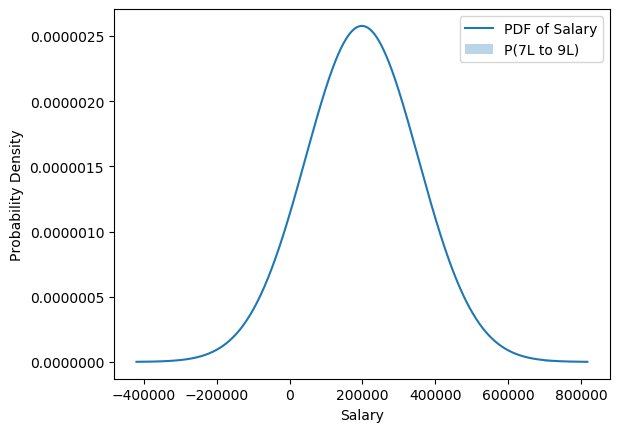

In [51]:
'''
The PDF gives you density at a single point, not a range. For a range 700000 to 900000,
you want the probability P(700000 ≤ X ≤ 900000), which is the area under the PDF curve.
To get that, we assume salary follows a normal distribution and use mean + std from your data.
'''
# 1. Calculate probability for range 700k to 900k
# Get mean and std of salary column
mu = dataset['salary'].mean()  # population mean
sigma = dataset['salary'].std()  # population std

# Probability between 700k and 900k using CDF
prob = stats.norm.cdf(900000, loc=mu, scale=sigma) - stats.norm.cdf(700000, loc=mu, scale=sigma)
print(f"Mean salary: {mu:.0f}")
print(f"Std salary: {sigma:.0f}")
print(f"P(700000 ≤ salary ≤ 900000) = {prob:.4f} or {prob*100:.2f}%")

# 2. PDF curve values
#The PDF itself at any point 
x = 800000  # example point
pdf_value = stats.norm.pdf(x, loc=mu, scale=sigma)
print(f"PDF at 8 LPA = {pdf_value:.2e}")

# 3. Visualize it
import matplotlib.pyplot as plt
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.plot(x, y, label='PDF of Salary')
plt.fill_between(x, y, where=(x>=700000) & (x<=900000), alpha=0.3, label='P(7L to 9L)')
plt.xlabel('Salary')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

 # 11) Test the similarity between the degree_t (Sci&Tech) with respect to etest_p and mba_p at significance level of 5%. (Make decision using Hypothesis testing)

In [57]:
'''
1. Define hypothesisH0: Mean etest_p = Mean mba_p for Sci&Tech grads
H1: Means are different
α = 0.05
2. Python code - paired t-test or Wilcoxon
'''
# Filter only Sci&Tech students
df_scitech = dataset[dataset['degree_t'] == 'Sci&Tech'][['etest_p','mba_p']]
etest = df_scitech['etest_p']
mba = df_scitech['mba_p']
corr, p_val = stats.pearsonr(etest, mba)
print(f"Correlation = {corr:.3f}, p = {p_val:.4f}")
# Decision at 5% significance
alpha = 0.05
if p_value < alpha:
    print(f"Reject H0: Salaries are significantly different at 5% level")
else:
    print(f"Fail to reject H0: No significant difference in salaries at 5% level")

Correlation = 0.248, p = 0.0578
Reject H0: Salaries are significantly different at 5% level


In [58]:
# 12) Which parameter is highly correlated with salary?
# Only numeric columns
numeric_df = dataset.select_dtypes(include=['number'])

# Correlation with salary, sorted
corr_with_salary = numeric_df.corr()['salary'].drop('salary').sort_values(ascending=False)

print("Correlation with salary:")
print(corr_with_salary)

# Highest positive correlation
print(f"\nMost positively correlated: {corr_with_salary.index[0]} = {corr_with_salary.iloc[0]:.3f}")
# Highest negative correlation
print(f"Most negatively correlated: {corr_with_salary.index[-1]} = {corr_with_salary.iloc[-1]:.3f}")

Correlation with salary:
salary_zscore           1.000000
salary_zscore_scipy     1.000000
salary_zscore_scaler    1.000000
ssc_p                   0.538090
hsc_p                   0.452569
degree_p                0.408371
etest_p                 0.186988
mba_p                   0.139823
sl_no                   0.002543
Name: salary, dtype: float64

Most positively correlated: salary_zscore = 1.000
Most negatively correlated: sl_no = 0.003


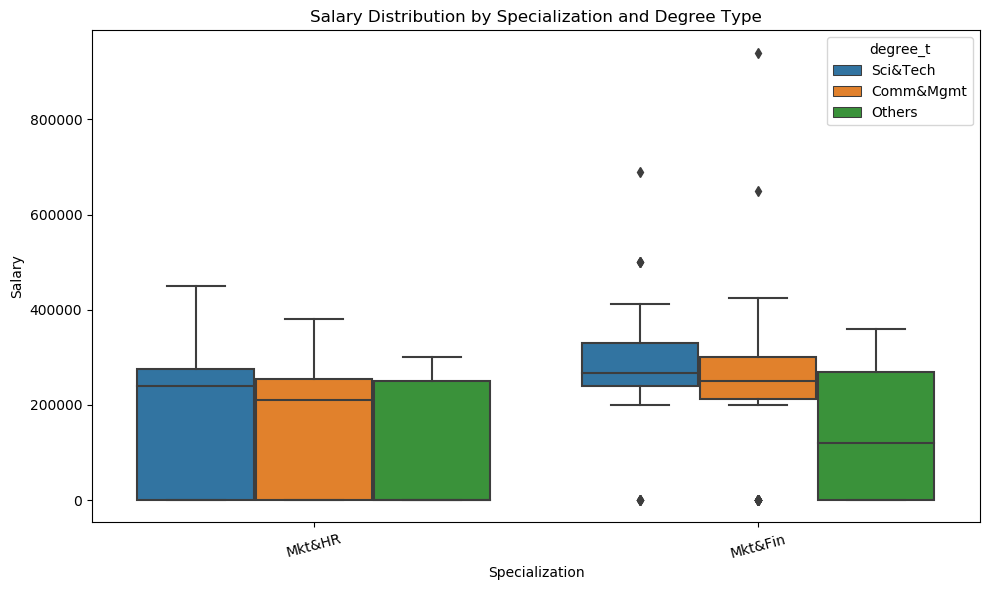

In [59]:
# 13) Plot any useful graph and explain it.
'''
For placement data, the most useful graph is a boxplot of salary by specialization + scatter of mba_p vs salary.
Shows where the money is and what drives it.1. Boxplot: Salary by Specialization.
'''
# 1. Boxplot: Salary by Specialization
plt.figure(figsize=(10,6))
sns.boxplot(data=dataset, x='specialisation', y='salary', hue='degree_t')
plt.title('Salary Distribution by Specialization and Degree Type')
plt.ylabel('Salary')
plt.xlabel('Specialization')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

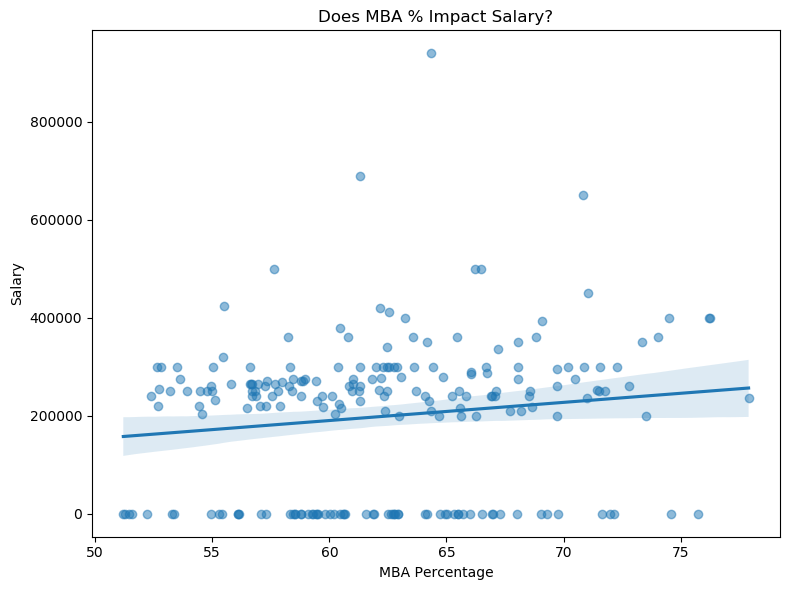

In [61]:
# 2. Scatter: mba_p vs salary with trendline
plt.figure(figsize=(8,6))
sns.regplot(data=dataset, x='mba_p', y='salary', scatter_kws={'alpha':0.5})
plt.title('Does MBA % Impact Salary?')
plt.xlabel('MBA Percentage')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

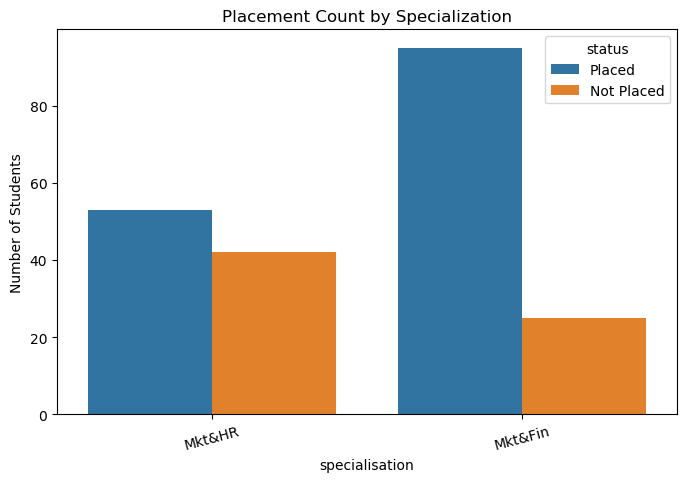

In [63]:
# 3. Countplot: Placed vs Specialization
plt.figure(figsize=(8,5))
sns.countplot(data=dataset, x='specialisation', hue='status')
plt.title('Placement Count by Specialization')
plt.ylabel('Number of Students')
plt.xticks(rotation=15)
plt.show()